In [1]:
pip install -q langgraph langchain-openai langchain-google-genai

Note: you may need to restart the kernel to use updated packages.


In [2]:
from getpass import getpass
openai_api_key = getpass("Enter your OpenAI API Key: ")
import os
os.environ["OPENAI_API_KEY"] = openai_api_key

In [3]:
from typing import Annotated,TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [4]:
class ReplyState(TypedDict):
    reply: str            # the one field every node will read and update

In [5]:
def add_greeting(state: ReplyState):
    print(" [node] add_greeting")
    return {"reply": state["reply"] + "Hello! "}

In [6]:
def add_answer(state: ReplyState):
    print(" [node] add_answer")
    return {"reply": state["reply"] + "Your order ships tomorrow. "}

In [7]:
def add_signature(state: ReplyState):
    print(" [node] add_signature")
    return {"reply": state["reply"] + "The support team."}

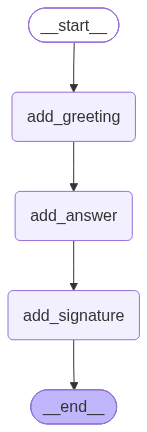

In [8]:
builder = StateGraph(ReplyState)

#Nodes : a name, and the function to run
builder.add_node("add_greeting", add_greeting)
builder.add_node("add_answer", add_answer)
builder.add_node("add_signature", add_signature)

#Edges : from node, to node
builder.add_edge(START, "add_greeting")
builder.add_edge("add_greeting", "add_answer")
builder.add_edge("add_answer", "add_signature")
builder.add_edge("add_signature", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
result = graph.invoke({"reply": ""})
print(result)


 [node] add_greeting
 [node] add_answer
 [node] add_signature
{'reply': 'Hello! Your order ships tomorrow. The support team.'}


In [10]:
class TicketState(TypedDict):
    text: str # what the customer wrote
    reply: str # what we  send back

def route_ticket(state: TicketState) -> str:
   """A router returns the NAME of the next node - just a string."""
   if "refund" in state["text"].lower():
       return "billing"
   else:
       return "general"

In [16]:

from langchain_openai import ChatOpenAI

def billing(state: TicketState):
    print(" [node] billing")
    llm = ChatOpenAI(model_name="gpt-4o-mini")
    # return {"reply": "Our building team will review your fund within 2 working days. "}
    result = llm.invoke("What day is today?")
    return {"reply": result.content}

def general(state: TicketState):
    print(" [node] general")
    return {"reply": "Thanks for your message - we will get back to you soon. "}

e:\GENAI-PEP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


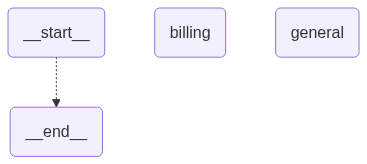

In [13]:
ticket_builder = StateGraph(TicketState)
ticket_builder.add_node("billing", billing)
ticket_builder.add_node("general", general)

# conditional edge : instead of a fixed START -> node edge,
# ask the router which node should run

ticket_builder.add_conditional_edges(START, route_ticket)

ticket_builder.add_edge("billing", END)
ticket_builder.add_edge("general", END)

ticket_graph = ticket_builder.compile()
display(Image(ticket_graph.get_graph().draw_mermaid_png()))




In [15]:
ticket_result = ticket_graph.invoke({"text": "I want a refund", "reply": ""})
print(ticket_result["reply"])

 [node] billing
Our building team will review your fund within 2 working days. 
